## Imports

In [1]:
# Imports and constants for UG analysis
# Run imports and constants for UG analysis. 
import random
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from scipy import cluster, stats
from scipy import signal
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from scipy.signal import spectrogram

# In notebooks __file__ is not defined. Use cwd as fallback while keeping os.path usage.
if '__file__' in globals():
    SRI_FOLDER = os.path.dirname(os.path.abspath(__file__))
else:
    SRI_FOLDER = os.getcwd()
PROJECT_FOLDER = os.path.dirname(SRI_FOLDER)
DATA_FOLDER = os.path.join(PROJECT_FOLDER, 'data')
OUTPUT_DATA_FOLDER = os.path.join(DATA_FOLDER, 'output_data')
FIG_FOLDER = os.path.join(PROJECT_FOLDER, 'figs')
SFC_FOLDER = os.path.join(OUTPUT_DATA_FOLDER, 'channel_sfc')

print(os.getcwd())
from utils import sessions as ses
from utils import sri_master as sri

SUBJECT = ['airp', 'braz']
SESSIONS = dict(zip(SUBJECT, [ses.AIRPORT_SESSIONS, ses.BRAZOS_SESSIONS]))
ROTATION = dict(zip(ses.AIRPORT_SESSIONS + ses.BRAZOS_SESSIONS, 
                    ses.AIRPORT_ROTATION + ses.BRAZOS_ROTATION))
STORAGE_PATHS = [r"X:\storage\rawdata", r"Y:\storage\rawdata", r"W:\storage\rawdata"] # santacruz2, santacruz1, santacruz3
SAVE_FOLDER = {}
for i, sessions in enumerate([ ses.AIRPORT_SESSIONS_1, ses.AIRPORT_SESSIONS_2, ses.BRAZOS_SESSIONS ]):
    for session in sessions:
        SAVE_FOLDER[session] = STORAGE_PATHS[i]

# plotting constants
SUBJECT_COLOR = dict(zip(SUBJECT, ['g', 'b'])) # airp is green, braz is blue.
ROTATION_CLR = {50: 'blue', 90: 'red', 270: 'green', 310: 'orange'}

c:\Users\seano\anaconda3\envs\ug_proj\Lib\site-packages\numpy\__init__.py:109: UserWarning: mkl-service package failed to import, therefore Intel(R) MKL initialization ensuring its correct out-of-the box operation under condition when Gnu OpenMP had already been loaded by Python process is not assured. Please install mkl-service package, see http://github.com/IntelPython/mkl-service
  from . import _distributor_init


c:\Users\seano\OneDrive - The University of Texas at Austin\Documents\GitHub\NeuronTracking\sri
Imported libraries!
Imported bmi_python libraries!


c:\Users\seano\OneDrive - The University of Texas at Austin\Documents\GitHub\bmi_python\riglib\blackrock\cerelink.py:13: UserWarning: Unable to import cerebus library. Check if is installed if using the Blackrock NeuroPort system
  warnings.warn("Unable to import cerebus library. Check if is installed if using the Blackrock NeuroPort system")


## Tracking object initialization & LFP reading

In [ ]:
#%% Initialize tracking objects
# Initialize tracking objects for Airport and Brazos.

# airp = sri.Tracking('airp', 
#                     sessions=SESSIONS['airp'][0:5],
#                     rotation=ROTATION,
#                     save_folder=SAVE_FOLDER)

braz = sri.Tracking('braz', 
                    sessions=SESSIONS['braz'], 
                    rotation=ROTATION, 
                    save_folder=SAVE_FOLDER)



In [ ]:
#%% Read LFP data for tracking objects
# Read LFP data for each session in the tracking objects.
# sri.read_lfp_later(airp)
sri.read_lfp_later(braz)

## SFC Extraction

### SFC Function per unit

In [ ]:
# SFC function per unit
def sfc_of_single_unit(subj: sri.Tracking, session: str, unit_code: str, channel: int, getNeighbors: bool = False, rand: bool = False):
    """
    Plot trial-averaged SFC for each session in a tracked neuron.
    
    cluster: usage like airp.useful_clusters.iloc[0]
    title: for the title and the saved filename
    rand: if this is to randomized aligned points.   
    
    """
    
    start_sec, end_sec = -1, 1

    bmi = subj.raw_data[session]
    ns2 = bmi.ns2file
    ind = bmi.index
    
    spike_times = bmi.pklfile['spks'].get(unit_code) # Spike times
    fs = 1000 # Sampling frequency

    lfp = ns2.getdata()['data'][channel] # Read LFP data

    # if lfp is None or len(lfp) == 0:
    #     raise ValueError(f"LFP data for session {session} and channel {channel} is empty or None.")
    
    # [Estimate firing rate] - upsampled to the same rate as LFP
    fr = sri.__calc_firing_rate(spike_times)
    fr_time  = np.arange(0, len(fr) / 20, 1 / 20)
    lfp_time = np.arange(0, len(lfp) / fs, 1 / fs)
    interp_func = interp1d(fr_time, fr, kind='linear', fill_value='extrapolate')
    fr = interp_func(lfp_time)
    
    # All non-error-clamped trials in the first block
    trial = ind[(ind['block_type']==1)&(ind['error_clamp']==0)] 
    align_pts = np.array(bmi.rpp_target[trial['trial_number']] / 30, dtype=int)
    
    # This is for randomized align_pts
    if rand: 
        align_pts = (np.random.random(len(align_pts)) * align_pts[-1]).astype(int)
    
    # Variable structures
    N_trials = len(align_pts)

    N_pts = int(0.6*fs) # Use N_pts//2 data points to compute spectrum
    N_freqs = N_pts//2 + 1 # So we have N_freqs of frequency for the spectrums
    f = np.fft.rfftfreq(N_pts, 1/fs)
    
    # Divide the aligned period (from start_sec to end_sec around align_pts) into N_timesteps sections
    N_timesteps = 100
    t = np.linspace(start_sec, end_sec, N_timesteps)
    
    # Create a matrix to store all the detailed align points
    fine_align_pts = np.zeros((N_trials, N_timesteps), dtype=int)
    for t in range(N_trials):
        fine_align_pts[t] = np.linspace(align_pts[t] + start_sec * fs, 
                                        align_pts[t] + end_sec * fs, 
                                        N_timesteps, 
                                        dtype=int)
    
    coherogram = np.zeros((1, N_freqs))

    f_bands = [(1, 4), (5, 8), (9, 12), (13, 30), (31, 50)] # divide frequencies into bins for delta, theta, alpha, beta, gamma
    
    session_coherences = np.zeros((N_trials, len(f_bands)))
    
    for t in range(N_trials):
        Sxx = np.zeros(int(N_pts/2+1)) # Field spectrum.
        Syy = np.zeros(int(N_pts/2+1)) # Spike spectrum.
        Sxy = np.zeros(int(N_pts/2+1), dtype=complex) # Cross spectrum.

        for ts in range(N_timesteps):
            pt = fine_align_pts[t, ts]

            field_raw = lfp[pt-N_pts//2: pt+N_pts//2]
            spike_raw = fr[pt-N_pts//2: pt+N_pts//2]
            sxx, syy, sxy = sri.calc_spectrum(spike_raw, field_raw, fs=1000)

            # Directly adding the averaged values
            Sxx += (sxx / N_trials)
            Syy += (syy / N_trials)
            Sxy += (sxy / N_trials)

        cohr = abs(Sxy) / np.sqrt(Syy) / np.sqrt(Sxx)
        coherogram = cohr

        coherences = np.zeros(len(f_bands))
        coherences_std = np.zeros(len(f_bands))

        for i in range(len(f_bands)):
            f_low, f_high = f_bands[i]
            idx_low = np.argmin(np.abs(f - f_low))
            idx_high = np.argmin(np.abs(f - f_high))
            
            coherence = coherogram[idx_low:idx_high].mean() # Average coherence in the frequency band
            coherence_std = coherogram[idx_low:idx_high].std() / np.sqrt(coherogram.shape)

            
        
            coherences[i] = coherence
            # coherences_std[i] = coherence_std

        session_coherences[t] = coherences

    # print the error and skip if any error occurs (e.g., no spike times, or not enough data points for the aligned period)
        
    return np.array(session_coherences)

### Run SFC Function: save per unit

In [ ]:
# Run SFC Function: save per unit
for subj in [braz]:
    all_channels = np.array(subj.useful_channel)
    processed_channels = []

    with os.scandir(SFC_FOLDER) as entries: # find all channels already extracted and saved
        for entry in entries:
            if entry.is_file() and entry.name.endswith('.pkl'):
                processed_channels.append(int(entry.name[-7:-4]))

    all_channels = np.setdiff1d(all_channels, processed_channels)

    channels = np.random.choice(all_channels, min(10, len(all_channels)), replace=False) # Randomly select 10 channels or all if less than 10
    # print(f'{subj.subject} - Selected channels: {channels}')
    print(f"{subj.subject} - Remaining channels to process: {len(all_channels)}")
    print(f"{subj.subject} - Selected channels: {[int(x) for x in channels]}")

    for ch in channels:
        ch_df = subj.useful_df[subj.useful_df['channel'] == ch]
        ch_df = ch_df.dropna(subset=['cluster_ID']) # Drop rows where cluster_ID is NaN
        sfc_df = pd.DataFrame(columns=['session', 'date', 'channel', 'unit_code', 'coherogram', 'wf_cluster_ID'])

        for unit in range(len(ch_df)):
            unit_code = ch_df.iloc[unit]['unit_code']
            session = ch_df.iloc[unit]['session']
            channel = ch_df.iloc[unit]['channel']
            date = ch_df.iloc[unit]['date']
            cluster_ID = int(ch_df.iloc[unit]['cluster_ID'])

            print(f'Processing unit {unit_code} in session {session} on channel {channel}')
            try: 
                out = sfc_of_single_unit(subj, session, unit_code, channel)
            except Exception as e:
                print(f'Error occurred while processing unit {unit_code} in session {session}')
                continue
            
            sfc_df = pd.concat([sfc_df, pd.DataFrame({
                'session': [session],
                'date': [date],
                'channel': [channel],
                'unit_code': [unit_code],
                'coherogram': [out],
                'wf_cluster_ID': [cluster_ID]
            })], ignore_index=True)

        # Save the results for this channel
        ch_string = str(ch).zfill(3)  # Pad channel number with zeros to make it 3 digits
        save_path = os.path.join(SFC_FOLDER, f'{subj.subject}_sfc_ch{ch_string}.pkl')
        sfc_df.to_pickle(save_path)
        print(f'Saved SFC for channel {ch} to {save_path}')

## SFC Similarity

### Calc cluster SFC similarity function

In [2]:
#%% Calc cluster sfc similarity function
# calc cluster sfc similarity function
def calc_cluster_sfc_similarity(subj: sri.Tracking = None, sfc_df: pd.DataFrame = None, cID_1: int = None, cID_2: int = None):
        """
        Calculate the similarity score for each pair of units within the same channels across all sessions.
        Here we use pearson correlation and Euclidean distance to estimate total similarity.
        The similarity data are stored in self.sim_df: pd.DataFrame.
        
        Each row will be the similarity results from one useful channel.
        There will be 4 columns: 'correlation', 'euclidean', 'unit', and 'total'.
        
        The 'unit' column for each row is a list of units in that channel.
        The other columns store matrices of similarity whose shapes are (m, m),
        where m is the number of units across all sessions in that channel. 
        """
        
        # [[sfc_sim_df]] - stores the total similarity matrix for each channel

        if subj is not None: 
            if sfc_df is None:
                sfc_df = subj.sfc_df
        else: 
            if sfc_df is None:
                raise ValueError("If 'subj' is not provided, 'sfc_df' must be provided.")
            
        if cID_1 is None or cID_2 is None:
            cID_1, cID_2 = np.random.choice(subj.sfc_df['cluster_ID'].unique(), 2, replace=False)


        # sfc_sim_df = pd.DataFrame(columns=['correlation', 'euclidean', 'unit']) - move this to other code running it

        c1_df = sfc_df[sfc_df['wf_cluster_ID']==cID_1].sort_values(by='date')
        c2_df = sfc_df[sfc_df['wf_cluster_ID']==cID_2].sort_values(by='date')

        sim_dict = dict() # stores dataframes for each metric
        sim_dict['clusters'] = (cID_1, cID_2)

        for metric in ['correlation', 'euclidean']:
            sim_temp = np.zeros((len(c1_df), len(c2_df))) # stores similarity

            for i in range(len(c1_df)):
                for j in range(len(c2_df)):
                    wf1 = c1_df['coherogram'].iloc[i][:, 0] # Use the first frequency band (Delta) for similarity calculation
                    wf2 = c2_df['coherogram'].iloc[j][:, 0] # Use the first frequency band (Delta) for similarity calculation

                    exclude_indices = np.where(np.isnan(wf1) | np.isnan(wf2))[0]

                    if len(exclude_indices) > 0:
                        wf1 = np.delete(wf1, exclude_indices)
                        wf2 = np.delete(wf2, exclude_indices)

                    sim_temp[i,j] = sri.Tracking.similarity(
                        wf1,
                        wf2,
                        metric
                    )

                    # print(f'[{metric}] Similarity between cluster {cID_1} (session {i}) and cluster {cID_2} (session {j}): {sim_temp[i,j]:.4f}')
            
            sim_temp = sri.Tracking.rescale(sim_temp, metric=metric)
            sim_dict[metric] = sim_temp

        sim_dict['total'] = (sim_dict['correlation'] + sim_dict['euclidean']) / 2
        return sim_dict

### Run calc cluster sfc similarity function, generate similarity matrices

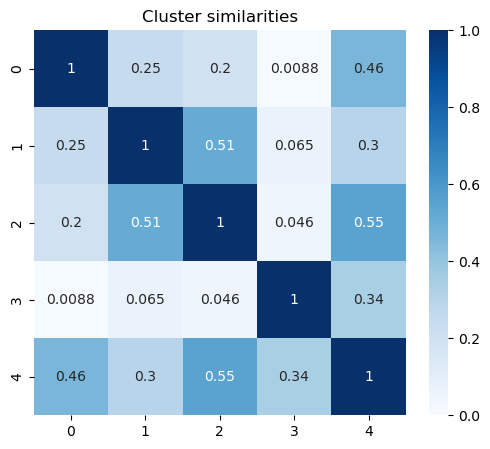

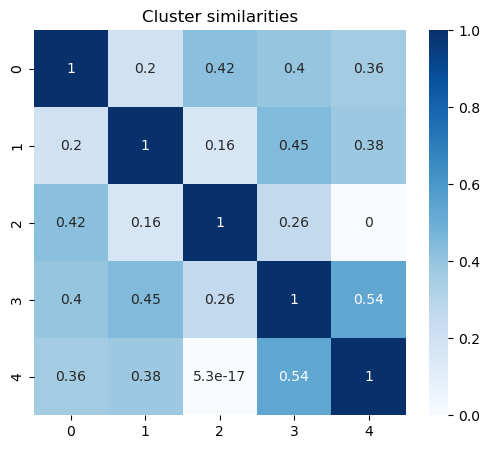

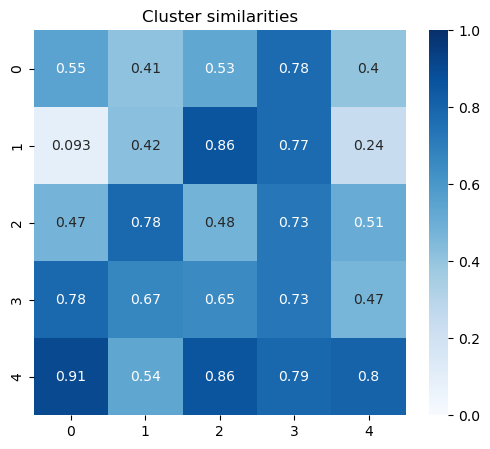

In [3]:
#%% Run calc_cluster_sfc_similarity function
# Run calc_cluster_sfc_similarity function

braz_useful_df = pd.read_pickle(os.path.join(OUTPUT_DATA_FOLDER, 'braz_useful_df.pkl'))
braz_sfc_df = pd.DataFrame(columns=['session', 'date', 'channel', 'unit_code', 'coherogram', 'wf_cluster_ID'])
with os.scandir(SFC_FOLDER) as entries: # find all channels already extracted and saved
        for entry in entries:
            if entry.is_file() and entry.name.endswith('.pkl'):
                braz_sfc_df = pd.concat([braz_sfc_df, pd.read_pickle(os.path.join(SFC_FOLDER, entry.name))], ignore_index=True)

cID_1, cID_2 = 2107, 2553

sim_dict = calc_cluster_sfc_similarity(sfc_df = braz_sfc_df, cID_1 = cID_1, cID_2 = cID_1)
# sim_df = pd.DataFrame(sim_dict)

plt.figure(figsize=(6, 5))
sns.heatmap(sim_dict['total'], annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Cluster similarities")
plt.show()

sim_dict = calc_cluster_sfc_similarity(sfc_df = braz_sfc_df, cID_1 = cID_2, cID_2 = cID_2)
# sim_df = pd.DataFrame(sim_dict)

plt.figure(figsize=(6, 5))
sns.heatmap(sim_dict['total'], annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Cluster similarities")
plt.show()

sim_dict = calc_cluster_sfc_similarity(sfc_df = braz_sfc_df, cID_1 = cID_1, cID_2 = cID_2)
# sim_df = pd.DataFrame(sim_dict)

plt.figure(figsize=(6, 5))
sns.heatmap(sim_dict['total'], annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Cluster similarities")
plt.show()

In [ ]:
temp_sfc_df = braz_sfc_df[braz_sfc_df['wf_cluster_ID']==cID_1].sort_values(by='date')

plotting_df = pd.DataFrame(columns=['date', 'coherence'])

for i in range(len(temp_sfc_df)):
    plotting_df = pd.concat([plotting_df, pd.DataFrame({
        'date': temp_sfc_df.iloc[i]['date'], 
        'coherence': temp_sfc_df.iloc[i]['coherogram'][:, 0]})], 
        ignore_index=True)
    
sns.violinplot(x='date', y='coherence', data=plotting_df)
plt.show()

In [ ]:
len(temp_sfc_df)

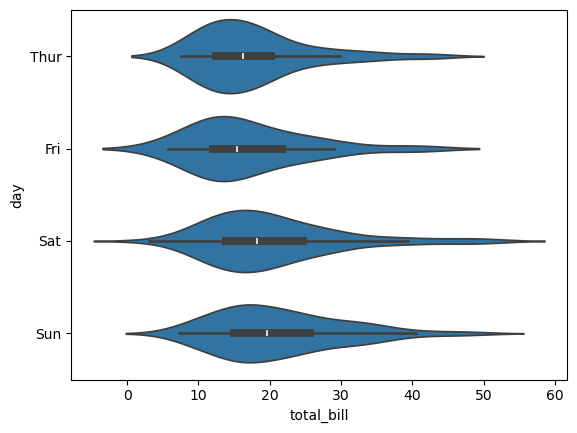

In [5]:
tips = sns.load_dataset("tips")

# Create a basic vertical violin plot
sns.violinplot(y="day", x="total_bill", data=tips)

# Display the plot
plt.show()

### Unfinished

In [ ]:
#%% UNFINISHED - thresholding for SFC functions
SAVEFIG = True
                
def get_sfc_threshold(subj: sri.Tracking, pct: float, PLOT: bool):

    # Obtain the amount of units for each channel in each session.
    # useful_channel is used to ensure there are at least 5 wavefroms
    subj_ch_session = np.zeros((len(subj.useful_channel), len(subj.sessions)))
    for i, ch in enumerate(subj.useful_channel):
        for j, session in enumerate(subj.sessions):
            subj_ch_session[i,j] = len(subj.useful_df[(subj.useful_df.session==session) & 
                                                      (subj.useful_df.channel==ch)])
    
    loc = np.zeros((len(subj.sessions), 2))
    loc[:,1] = np.arange(len(subj.sessions))
    
    threshold = []
    
    for it in range(200):
        
        print(f'{it} iteration')
        run = 0
        
        dist = []
        n_unit = []
        
        while len(dist) < 5000:
            
            run += 1        
            loc[:,0] = random.sample(range(len(subj.useful_channel)), len(subj.sessions))
            
            used_pair = []
            for l in loc:
                if subj_ch_session[int(l[0]), int(l[1])] != 0:
                    used_pair.append((int(subj.useful_channel[int(l[0])]), 
                                      subj.sessions[int(l[1])]))
            
            sim_temp = np.zeros((2, len(used_pair), len(used_pair)))
            for m, metric in enumerate(['correlation', 'euclidean']):
                for i, (ch1, ses1) in enumerate(used_pair):
                    for j, (ch2, ses2) in enumerate(used_pair):
                        
                        # transform sfc values per trial to a 1D array for similarity calculation
                        # do this for every frequency band

                        cID_1 = int(subj.useful_df[(subj.useful_df['channel']==ch1)&(subj.useful_df['session']==ses1)]['cluster_ID'])
                        cID_2 = int(subj.useful_df[(subj.useful_df['channel']==ch2)&(subj.useful_df['session']==ses2)]['cluster_ID'])

                        # Randomly pick one if > 1 unit in that channel.
                        cID_1 = cID_1.iloc[random.randint(0, len(cID_1)-1) if len(cID_1) > 1 else 0]
                        cID_2 = cID_2.iloc[random.randint(0, len(cID_2)-1) if len(cID_2) > 1 else 0]

                        idx_1 = subj.sfc_df[(subj.sfc_df['cluster_ID']==cID_1)]['sessions'].index(ses1) # find which unit in the cluster corresponds to the selected unit based on session and channel
                        idx_2 = subj.sfc_df[(subj.sfc_df['cluster_ID']==cID_2)]['sessions'].index(ses2) # find which unit in the cluster corresponds to the selected unit based on session and channel

                        wf1 = subj.sfc_df[(subj.sfc_df['cluster_ID']==cID_1)]['coherograms'][idx_1, :, 0] # Use the first frequency band (Delta) for similarity calculation
                        wf2 = subj.sfc_df[(subj.sfc_df['cluster_ID']==cID_2)]['coherograms'][idx_2, :, 0] # Use the first frequency band (Delta) for similarity calculation

                        sim_temp[m,i,j] = subj.similarity(wf1, wf2, metric)
                sim_temp[m] = subj.rescale(sim_temp[m], metric=metric)
            total_temp = sim_temp.mean(axis=0)
        
            dist += [float(total_temp[i, j]) 
                     for i in range(len(total_temp)) 
                     for j in range(i + 1, len(total_temp))]
            n_unit.append(len(total_temp))
            
            # if PLOT:
            #     plt.figure(figsize=(5,5)) # Fig size (5,5) for airport, (7,10) for brazos
            #     plt.pcolormesh(subj_ch_session,cmap='Greys', vmin=0, vmax=5)
            #     plt.yticks(np.arange(len(subj.useful_channel)), subj.useful_channel, fontsize=5)
            #     plt.xticks(np.arange(len(subj.sessions)), subj.sessions, rotation=90, fontsize=5)
            #     plt.xlabel('Session', fontsize=5)
            #     plt.ylabel('Channel', fontsize=5)
            #     plt.grid(True, color='k', lw=0.1)
                
            #     for l in loc:
            #         c = 'r' if subj_ch_session[int(l[0]), int(l[1])] == 0 else 'k'
            #         plt.scatter(l[1]+0.5, l[0]+0.5, marker='s', c=c, s=5)
            #     plt.show()
                
            #     plt.figure(figsize=(4,4))
            #     plt.pcolormesh(total_temp, cmap='Greys', vmax=0.7, vmin=0)
            #     plt.xticks([])
            #     plt.yticks([])
            #     if SAVEFIG:
            #         plt.savefig(os.path.join(FIG_FOLDER, f'[{subj.subject}]_null_total_similarity.svg'))
            #     plt.show()
                
        
        thres = np.percentile(dist, pct)
                
        if PLOT:
            plt.figure(figsize=(4,4))
            plt.hist(dist, bins=80, density=True)
            # plt.axvline(np.mean(dist), c='k', ls='--', label=f'Mean: {mean:.3f}')
            plt.axvline(thres, c='r', ls='--', label=f'Threshold = {thres:.3f}')
            plt.legend(frameon=False)
            plt.xlabel('Total similarity')
            plt.ylabel('Density')
            if SAVEFIG:
                plt.savefig(os.path.join(FIG_FOLDER, f'[{subj.subject}]_null_distribution_[{it}].svg'))
            plt.show()
            
        threshold.append(thres)
    
    plt.figure(figsize=(4,4))
    plt.hist(threshold, bins=30)
    plt.xlabel('Similarity threshold')
    plt.ylabel('Count')
    plt.axvline(np.mean(threshold), c='k', ls='--', lw=2)
    plt.title(f'Mean: {np.mean(threshold):.3f}, std: {np.std(threshold):.3f}')
    if SAVEFIG:
        plt.savefig(os.path.join(FIG_FOLDER, f'[{subj.subject}]_thresholds.svg'))
    plt.show()

## Outdated SFC functions

In [ ]:
#%% SFC function
# SFC function
def sfc_of_tracked_neuron(subj: sri.Tracking, cluster: pd.Series, getNeighbors: bool = False, rand: bool = False):
    """
    Plot trial-averaged SFC for each session in a tracked neuron.
    
    cluster: usage like airp.useful_clusters.iloc[0]
    title: for the title and the saved filename
    rand: if this is to randomized aligned points.   
    
    """
    
    start_sec, end_sec = -1, 1
    
    # plt.figure(figsize=(4,4)) # Each line is data from a neuron
    
    sessions = []

    cluster_coherences = [] # To store the coherences for each cluster across sessions
    
    for n in range(cluster.n_unit): # For each neuron in a cluster
        session, unit_code, channel = cluster.neuron.df[['session','unit_code','channel']].iloc[n]
        print(session)
        sessions.append(session)

        bmi = subj.raw_data[session]
        ns2 = bmi.ns2file
        ind = bmi.index
        
        try:
            spike_times = bmi.pklfile['spks'].get(unit_code) # Spike times
            fs = 1000 # Sampling frequency
    
            lfp = ns2.getdata()['data'][channel] # Read LFP data
            
            # [Estimate firing rate] - upsampled to the same rate as LFP
            fr = sri.__calc_firing_rate(spike_times)
            fr_time  = np.arange(0, len(fr) / 20, 1 / 20)
            lfp_time = np.arange(0, len(lfp) / fs, 1 / fs)
            interp_func = interp1d(fr_time, fr, kind='linear', fill_value='extrapolate')
            fr = interp_func(lfp_time)
            
            # All non-error-clamped trials in the first block
            trial = ind[(ind['block_type']==1)&(ind['error_clamp']==0)] 
            align_pts = np.array(bmi.rpp_target[trial['trial_number']] / 30, dtype=int)
            
            # This is for randomized align_pts
            if rand: 
                align_pts = (np.random.random(len(align_pts)) * align_pts[-1]).astype(int)
            
            # Variable structures
            N_trials = len(align_pts)

            N_pts = int(0.6*fs) # Use N_pts//2 data points to compute spectrum
            N_freqs = N_pts//2 + 1 # So we have N_freqs of frequency for the spectrums
            f = np.fft.rfftfreq(N_pts, 1/fs)
            
            # Divide the aligned period (from start_sec to end_sec around align_pts) into N_timesteps sections
            N_timesteps = 100
            t = np.linspace(start_sec, end_sec, N_timesteps)
            
            # Create a matrix to store all the detailed align points
            fine_align_pts = np.zeros((N_trials, N_timesteps), dtype=int)
            for t in range(N_trials):
                fine_align_pts[t] = np.linspace(align_pts[t] + start_sec * fs, 
                                                align_pts[t] + end_sec * fs, 
                                                N_timesteps, 
                                                dtype=int)
            
            coherogram = np.zeros((1, N_freqs))

            f_bands = [(1, 4), (5, 8), (9, 12), (13, 30), (31, 50)] # divide frequencies into bins for delta, theta, alpha, beta, gamma
            
            session_coherences = np.zeros((N_trials, len(f_bands)))
            
            for t in range(N_trials):
                Sxx = np.zeros(int(N_pts/2+1)) # Field spectrum.
                Syy = np.zeros(int(N_pts/2+1)) # Spike spectrum.
                Sxy = np.zeros(int(N_pts/2+1), dtype=complex) # Cross spectrum.

                for ts in range(N_timesteps):
                    pt = fine_align_pts[t, ts]

                    field_raw = lfp[pt-N_pts//2: pt+N_pts//2]
                    spike_raw = fr[pt-N_pts//2: pt+N_pts//2]
                    sxx, syy, sxy = sri.calc_spectrum(spike_raw, field_raw, fs=1000)

                    # Directly adding the averaged values
                    Sxx += (sxx / N_trials)
                    Syy += (syy / N_trials)
                    Sxy += (sxy / N_trials)

                cohr = abs(Sxy) / np.sqrt(Syy) / np.sqrt(Sxx)
                coherogram = cohr

                coherences = np.zeros(len(f_bands))
                coherences_std = np.zeros(len(f_bands))

                for i in range(len(f_bands)):
                    f_low, f_high = f_bands[i]
                    idx_low = np.argmin(np.abs(f - f_low))
                    idx_high = np.argmin(np.abs(f - f_high))
                    
                    coherence = coherogram[idx_low:idx_high].mean() # Average coherence in the frequency band
                    coherence_std = coherogram[idx_low:idx_high].std() / np.sqrt(coherogram.shape)

                    
                
                    coherences[i] = coherence
                    # coherences_std[i] = coherence_std

                session_coherences[t] = coherences

            cluster_coherences.append(session_coherences)

        # print the error and skip if any error occurs (e.g., no spike times, or not enough data points for the aligned period)
        except Exception as e:
            print(f'Error occurred while processing cluster {cluster.cluster_ID} in session {session}')
            pass
        
    return np.array(cluster_coherences), np.array(sessions)

# out, ses = sfc_of_tracked_neuron(braz, braz.useful_clusters.iloc[1])

In [ ]:
#%% Run SFC function: select channels and only useful clusters
for subj in [braz]: # For each subject
    # all_channels = list(subj.useful_channel)
    all_channels = list(subj.useful_clusters['channel'].unique().astype(int)) # Get unique channels from useful_clusters
    channels = random.sample(all_channels, min(5, len(all_channels))) # Randomly select 5 channels or all if less than 5
    print(f'{subj.subject} - Selected channels: {channels}')
    # look through channel to find all clusters for that channel
    # then run sfc_of_tracked_neuron for each cluster and save the results

    # look through self.useful_clusters, maybe self.useful_df for info
    clusters = subj.useful_clusters[subj.useful_clusters['channel'].isin(channels)]

    print(f'Processing {len(clusters)} clusters for subject {subj.subject}.')

    with h5py.File(os.path.join(OUTPUT_DATA_FOLDER, f'{subj.subject}_sfc.h5'), 'a') as h5file:
        h5file.attrs['sessions'] = np.array(subj.all_sessions) 
        h5file.attrs['channels'] = np.array(channels)
        for cluster in clusters.itertuples():
            # print progress through clusters
            print(f'Cluster {cluster.cluster_ID} on channel {cluster.channel}: {clusters.index.get_loc(cluster.Index)+1}/{len(clusters)}')
            out, ses = sfc_of_tracked_neuron(subj, cluster)
            
            path = f'{cluster.channel}/{cluster.cluster_ID}' 
            grp = h5file.require_group(path)
            if "coherograms" in grp:
                del grp["coherograms"]  # Delete existing dataset if it exists
            grp.create_dataset("coherograms", data=out)
            grp.attrs['sessions'] = np.array(ses)

In [ ]:
#%% Visualize coherence over trials for each cluster in the tracking objects.
os.chdir(FIG_FOLDER)

with h5py.File(os.path.join(OUTPUT_DATA_FOLDER, f'braz_sfc.h5'), 'r') as h5file:
    # h5file.visit(print)  # Print all paths in the HDF5 file
    for channel in h5file.keys():
        print(f'Channel: {channel}')
        for cluster in h5file[channel].keys():
            print(f'  Cluster: {cluster}')
            coherograms = h5file[f'{channel}/{cluster}/coherograms'][:]
            sessions = h5file[f'{channel}/{cluster}/sessions'][:]
            print(f'    Coherograms shape: {coherograms.shape}')
            print(f'    Sessions: {[s.decode("utf-8") for s in sessions]}')  # Decode bytes to string

            num_plots = coherograms.shape[0]

            f_bands = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
            c_f_bands = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

            fig, axes = plt.subplots(num_plots, 1, figsize=(10, 4 * num_plots))
            
            for i in range(num_plots):
                x = np.arange(coherograms.shape[1]) + 1

                for j in range(coherograms.shape[2]):
                    y = coherograms[i, :, j]
                    axes[i].plot(x, y, color=c_f_bands[j], label=f'{f_bands[j]}')
                    y_mean = np.mean(y[~np.isnan(y)]);
                    axes[i].axhline(y=y_mean, color=c_f_bands[j], linestyle='--')
                    if j == 0:
                        axes[i].text(axes[i].get_xlim()[1], y_mean, s=f'{y_mean:.2f}', color = c_f_bands[j], va='bottom', ha='right')

                axes[i].set_ylim(0, 0.7)
                axes[i].set_title(f'Cluster {cluster} - Session {sessions[i].decode("utf-8")}')
                axes[i].set_xlabel('Trial Number')
                axes[i].legend()

            plt.tight_layout()
            plt.savefig(f'Channel_{channel}_{cluster}')

In [ ]:
#%% Generate trial-averaged SFC coherograms for useful clusters in the tracking objects.
# Generate SFC coherograms for each useful cluster in the tracking objects.

COHEROGRAM_FOLDER = r"C:\Users\seano\Downloads\coherograms"
os.chdir(COHEROGRAM_FOLDER)

for subj in [braz]: # For each subject

    subj.useful_clusters['stable_sfc'] = None

    # for k in range(len(subj.useful_clusters)): # Go through each useful cluster
    for k in range(1): # do one cluster for testing    
        print(f'Cluster [{k}]')
        example = subj.useful_clusters.iloc[k]
        title = f'[{subj.subject}]_SFC_[{k}]'
        out, ses = sri.sfc_of_tracked_neuron(subj, example, title)
            
        if out.ndim > 1:
            np.savetxt(f'{subj.subject}_c{k}_ses.csv', ses.T, delimiter=',', fmt='%s')
            np.save(f'{subj.subject}_c{k}.npy', out)
            print(f'{subj.subject}_c{k}: SFC saved.')
            
        else:
            print(f'{subj.subject}_c{k}: Not enough data for SFC calculation.')